# Define Problem

The goal of this project is to build a model that predicts the sale price of residential houses based on their available characteristics, such as size, quality, location, age, and other property features. The target variable is `SalePrice`. Model performance will be evaluated using Root Mean Squared Error (RMSE) between the logarithm of the predicted and actual sale prices, where a lower score indicates better performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression

# Load train/test data

In [2]:
df_train = pd.read_csv("data/train.csv")
df_test = pd.read_csv("data/test.csv")

## Exploratory Data Analysis

In [4]:
df_train.shape

(1460, 81)

In [5]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
df_test.shape

(1459, 80)

In [7]:
df_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [8]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [9]:
df_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Missing Values

In [10]:
missing_values = df_train.isnull().sum()

In [11]:
missing_values = missing_values[missing_values > 0]

In [12]:
missing_values

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

### Analyze target value

In [13]:
df_train["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

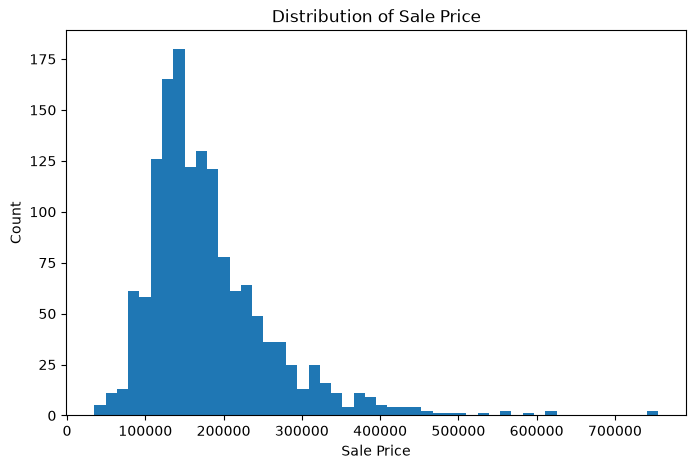

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(df_train["SalePrice"], bins = 50)
plt.xlabel("Sale Price")
plt.ylabel("Count")
plt.title("Distribution of Sale Price")
plt.show()

In [15]:
print(df_train["SalePrice"].isnull().sum())

0


### Looking for Correlations

In [16]:
corr_matrix = df_train.corr(numeric_only=True)
corr_matrix 

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,0.012609,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,-0.012713,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,-0.021998,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,-0.050298,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.005024,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420


### Create X and y

In [17]:
X = df_train.drop("SalePrice", axis = 1)
y = df_train["SalePrice"]

### Split into training / validation set

In [18]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size= 0.2, random_state = 42)

### Separate Numerical and Categorical Features

In [19]:
df_num = X.select_dtypes(include = ["int64", "float64"])

In [20]:
df_cat = X.select_dtypes(exclude = ["number"])

In [21]:
missing_num = missing_values[missing_values.index.isin(df_num.columns)]
missing_num

LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64

In [22]:
df_train.loc[
    df_train["GarageYrBlt"].isna(),
    ["GarageType", "GarageYrBlt"]
].head(20)

,GarageType,GarageYrBlt
39,NaN,NaN
48,NaN,NaN
78,NaN,NaN
88,NaN,NaN
89,NaN,NaN
99,NaN,NaN
108,NaN,NaN
125,NaN,NaN
127,NaN,NaN
140,NaN,NaN


In [23]:
missing_cat = missing_values[missing_values.index.isin(df_cat.columns)]

In [24]:
len(missing_cat)

16

In [25]:
cat_none = ["Alley","MasVnrType", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1",
            "BsmtFinType2", "FireplaceQu", "GarageType", "GarageFinish",
            "GarageQual", "GarageCond", "PoolQC", "Fence", "MiscFeature"]

In [26]:
len(cat_none)

15

In [27]:
cat_missing = ["Electrical"]

In [28]:
print("Numerical:", len(df_num))
print("Categorical:", len(df_cat))

Numerical: 1460
Categorical: 1460


### Create numerical pipeline

In [29]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy = "median")),
    ("scaler", StandardScaler())
])

In [30]:
garage_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler", StandardScaler())
])

### Create numerical pipeline

In [31]:
cat_none_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy = "constant", fill_value = "None")),
    ("onehot", OneHotEncoder(handle_unknown = "ignore"))
])

In [32]:
cat_missing_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [33]:
preprocessing = ColumnTransformer([
    ("num", num_pipeline, ["LotFrontage", "MasVnrArea"]),
    ("garage", garage_pipeline, ["GarageYrBlt"]),
    ("cat_none", cat_none_pipeline, cat_none),
    ("cat_missing", cat_missing_pipeline, cat_missing)
])

In [34]:
X_train_prepared = preprocessing.fit_transform(X_train)

In [35]:
X_valid_prepared = preprocessing.transform(X_valid)

In [36]:
X_train_prepared.shape

(1168, 86)

In [37]:
X_valid_prepared.shape

(292, 86)

# Select and Train model

## Create Baseline

In [39]:
baseline_model = LinearRegression()
baseline_model.fit(X_train_prepared, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](86,)","[ 7208.55, 17388.85,135016.64,..., -6401.96, -827.7 , 6460.77]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.795e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,86


In [40]:
y_valid_pred = baseline_model.predict(X_valid_prepared)

In [41]:
y_valid_score = baseline_model.score(X_valid_prepared, y_valid)
y_valid_score

0.6856419750436444

In [42]:
rmse = root_mean_squared_error(y_valid, y_valid_pred)
rmse

49104.26251622479

In [43]:
comparison = pd.DataFrame({
    "actual": y_valid,
    "predicted": y_valid_pred
})

comparison.head(10)

,actual,predicted
892,154500,147072.116292
1105,325000,304013.608236
413,115000,138427.837080
522,159000,144491.603659
1036,315500,354614.316471
614,75500,123526.669997
218,311500,164625.290755
1160,146000,169837.551031
649,84500,118127.831133
887,135500,122275.526127


In [44]:
comparison["error"] = comparison["actual"] - comparison["predicted"]

comparison.head(10)

,actual,predicted,error
892,154500,147072.116292,7427.883708
1105,325000,304013.608236,20986.391764
413,115000,138427.837080,-23427.837080
522,159000,144491.603659,14508.396341
1036,315500,354614.316471,-39114.316471
614,75500,123526.669997,-48026.669997
218,311500,164625.290755,146874.709245
1160,146000,169837.551031,-23837.551031
649,84500,118127.831133,-33627.831133
887,135500,122275.526127,13224.473873


### Cross-Validation score

In [45]:
baseline_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("model", baseline_model)
])

In [46]:
baseline_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](80,)","['Id','MSSubClass','MSZoning',...,'YrSold','SaleType','SaleCondition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,80
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('garage', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of

In [47]:
scores = cross_val_score(
    baseline_pipeline,
    X,
    y,
    scoring = "neg_root_mean_squared_error",
    cv = 5
)

In [48]:
rmse_scores = -scores
print(f"{rmse_scores.mean():.4f}")

48795.5782


In [49]:
print(rmse_scores)

[51379.81613854 48667.48754947 51257.07415409 38281.99346112
 54391.5199025 ]


In [50]:
print(rmse_scores.std())

5560.641741187517


## Random Forset

In [51]:
rf_model = RandomForestRegressor(random_state = 42)

In [52]:
rf_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("model", rf_model)
])

In [53]:
rf_scores = cross_val_score(
    rf_pipeline,
    X,
    y,
    scoring = "neg_root_mean_squared_error",
    cv = 5
)

In [54]:
rf_rmse_scores = -rf_scores

In [55]:
print(rf_rmse_scores.mean())

44231.000882540444


In [56]:
print(rf_rmse_scores.std())

5358.530924160052


## Ridge Regression

In [57]:
ridge_model = Ridge(alpha = 0.5)

In [58]:
ridge_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("model", ridge_model)
])

In [59]:
ridge_scores = cross_val_score(
    ridge_pipeline,
    X,
    y,
    scoring = "neg_root_mean_squared_error",
    cv = 5
)

In [60]:
ridge_rmse_scores = -ridge_scores

In [61]:
print(ridge_rmse_scores.mean())

48080.22423508305


In [62]:
print(ridge_rmse_scores.std())

5207.520250416004


## Extra Trees

In [63]:
extra_model = ExtraTreesRegressor(random_state=42)

In [64]:
extra_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("model", extra_model)
])

In [65]:
extra_trees_scores = cross_val_score(
    extra_pipeline,
    X,
    y,
    scoring = "neg_root_mean_squared_error",
    cv = 5
)

In [66]:
extra_trees_scores = - extra_trees_scores

In [67]:
print(extra_trees_scores.mean())

48410.9531945483


In [68]:
print(extra_trees_scores.std())

4548.283551342077


## Gradient Boosting

In [69]:
gradient_model = GradientBoostingRegressor(random_state=42)

In [70]:
gradient_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("model", gradient_model)
])

In [71]:
gradient_scores = cross_val_score(
    gradient_pipeline,
    X,
    y,
    scoring = "neg_root_mean_squared_error",
    cv = 5
)

In [72]:
gradient_scores = - gradient_scores

In [73]:
print(gradient_scores.mean())

44899.59831001643


In [74]:
print(gradient_scores.std())

3856.961123836579


## Voting Regressor

In [75]:
voting_model = VotingRegressor([
    ("rf", rf_pipeline),
    ("gb", gradient_pipeline)
])

In [76]:
voting_scores = cross_val_score(
    voting_model,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=5
)

In [77]:
voting_rmse_scores = -voting_scores

print(voting_rmse_scores.mean())
print(voting_rmse_scores.std())

43618.80592433053
4724.596786250105


## Stacking Regressor


In [78]:
stacking_model = StackingRegressor(
    estimators=[
        ("rf", rf_pipeline),
        ("gb", gradient_pipeline)
    ],
    final_estimator= LinearRegression()
)

In [79]:
stacking_scores = cross_val_score(
    stacking_model,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=5
)

In [80]:
stacking_rmse_scores = -stacking_scores

print(stacking_rmse_scores.mean())
print(stacking_rmse_scores.std())

43675.08088868181
4794.137520267247


In [81]:
score_dict = {"Linear Regression":{"RMSE Mean": round(float(rmse_scores.mean()),3),
                                   "RMSE Std": round(float(rmse_scores.std()),3)},
              "Random Forest":{"RMSE Mean": round(float(rf_rmse_scores.mean()),3),
                                   "RMSE Std": round(float(rf_rmse_scores.std()),3)},
              "Ridge Regression":{"RMSE Mean": round(float(ridge_rmse_scores.mean()),3),
                                   "RMSE Std": round(float(ridge_rmse_scores.std()),3)},
              "Extra Trees":{"RMSE Mean": round(float(extra_trees_scores.mean()),3),
                                   "RMSE Std": round(float(extra_trees_scores.std()),3)},
              "Gradient Boosting":{"RMSE Mean": round(float(gradient_scores.mean()),3),
                                   "RMSE Std": round(float(gradient_scores.std()),3)},
              "Voting Regressor":{"RMSE Mean": round(float(voting_rmse_scores.mean()),3),
                                   "RMSE Std": round(float(voting_rmse_scores.std()),3)},
              "Stacking Regressor": {"RMSE Mean": round(float(stacking_rmse_scores.mean()),3),
                                   "RMSE Std": round(float(stacking_rmse_scores.std()),3)}
             }

score_dict

{'Linear Regression': {'RMSE Mean': 48795.578, 'RMSE Std': 5560.642},
 'Random Forest': {'RMSE Mean': 44231.001, 'RMSE Std': 5358.531},
 'Ridge Regression': {'RMSE Mean': 48080.224, 'RMSE Std': 5207.52},
 'Extra Trees': {'RMSE Mean': 48410.953, 'RMSE Std': 4548.284},
 'Gradient Boosting': {'RMSE Mean': 44899.598, 'RMSE Std': 3856.961},
 'Voting Regressor': {'RMSE Mean': 43618.806, 'RMSE Std': 4724.597},
 'Stacking Regressor': {'RMSE Mean': 43675.081, 'RMSE Std': 4794.138}}

In [82]:
rmse_df = pd.DataFrame(score_dict)
rmse_df

,Linear Regression,Random Forest,Ridge Regression,Extra Trees,Gradient Boosting,Voting Regressor,Stacking Regressor
RMSE Mean,48795.578,44231.001,48080.224,48410.953,44899.598,43618.806,43675.081
RMSE Std,5560.642,5358.531,5207.520,4548.284,3856.961,4724.597,4794.138


## Hyperparameter Tuning

### Random Forest

In [83]:
param_distributions = {
    "model__n_estimators": [100, 200, 300, 500, 800],
    "model__max_depth": [None, 10, 20, 30, 40],
    "model__min_samples_split": [2, 4, 6, 8, 10],
    "model__min_samples_leaf": [1, 3, 5, 7, 9],
    "model__max_features": ["sqrt", "log2", None]
}

In [84]:
rf_random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

In [85]:
rf_random_search.fit(X,y)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 3, ...], 'model__min_samples_split': [2, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting th

In [86]:
rf_random_search.best_params_

{'model__n_estimators': 200,
 'model__min_samples_split': 2,
 'model__min_samples_leaf': 1,
 'model__max_features': None,
 'model__max_depth': 20}

In [87]:
print(-rf_random_search.best_score_)

44060.45603065318


In [88]:
rf_random_search.cv_results_["mean_train_score"]

array([-39429.97542716, -42080.36663993, -45768.56908476, -42449.17778068,
       -39377.0037907 , -34421.77158554, -42163.51048329, -34421.77158554,
       -42626.82470685, -45275.25561174, -30141.58804451, -42382.86231446,
       -34325.85287526, -48256.35659755, -36019.4219333 , -42213.48448054,
       -26082.86837683, -16872.58362715, -48269.00765798, -47103.11753393,
       -45303.797951  , -47120.7585775 , -38704.72808688, -34421.77158554,
       -45282.18195081, -44220.59877392, -48256.35659755, -47347.19232582,
       -44241.83775563, -25506.3073097 , -45475.91784823, -45527.07951732,
       -42534.09805455, -35503.95499109, -34799.55329976, -37377.17738979,
       -45599.89994666, -40535.60542069, -47120.7585775 , -16712.76299645,
       -42237.19765802, -39306.77746423, -47201.9525725 , -39428.67335147,
       -16766.31536756, -31169.07704385, -31173.26260031, -31144.40842485,
       -42606.86358627, -40118.41235996])

In [89]:
rf_random_search.cv_results_["mean_test_score"]

array([-45890.77696101, -47086.89150731, -47898.07651047, -46639.26278738,
       -45967.75079691, -44819.31599478, -46987.21342199, -44819.31599478,
       -46642.61533666, -48162.73158226, -44558.05527557, -46565.63184538,
       -44760.47893249, -49957.84771856, -45737.75196426, -46882.96091924,
       -44576.10775216, -44060.45603065, -49924.82051349, -49173.17430107,
       -48277.32645223, -49313.20953244, -45585.65392938, -44819.31599478,
       -48084.04534694, -47163.02904028, -49957.84771856, -49347.07305823,
       -47208.29529685, -44646.74004736, -47835.27845291, -47859.09512432,
       -46786.12626582, -44954.63964595, -44802.51421431, -45349.97904589,
       -48310.03404514, -45866.94243345, -49313.20953244, -44783.1444256 ,
       -47056.16139685, -45919.46164344, -49242.41189296, -45976.75655101,
       -44141.78080968, -44468.72982615, -44357.47202187, -44389.57718963,
       -46606.69322504, -45754.39134318])

In [90]:


results = pd.DataFrame(rf_random_search.cv_results_)
results["train_rmse"] = -results["mean_train_score"]
results["cv_rmse"] = -results["mean_test_score"]

results[
    [
        "mean_train_score",
        "mean_test_score",
        "param_model__n_estimators",
        "param_model__max_depth",
        "param_model__min_samples_split",
        "param_model__min_samples_leaf",
        "param_model__max_features"
    ]
]

,mean_train_score,mean_test_score,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features
0,-39429.975427,-45890.776961,100,20,6,9,NaN
1,-42080.366640,-47086.891507,200,40,4,3,log2
2,-45768.569085,-47898.076510,100,10,10,9,sqrt
3,-42449.177781,-46639.262787,200,20,4,5,sqrt
4,-39377.003791,-45967.750797,200,40,4,9,NaN
5,-34421.771586,-44819.315995,200,30,10,5,NaN
6,-42163.510483,-46987.213422,100,40,6,3,log2
7,-34421.771586,-44819.315995,200,None,8,5,NaN
8,-42626.824707,-46642.615337,300,10,2,5,sqrt
9,-45275.255612,-48162.731582,300,30,4,5,log2


In [91]:
results[
    [
        "train_rmse",
        "cv_rmse",
        "param_model__n_estimators",
        "param_model__max_depth",
        "param_model__min_samples_split",
        "param_model__min_samples_leaf",
        "param_model__max_features"
    ]
].sort_values("cv_rmse").head(10)

,train_rmse,cv_rmse,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features
17,16872.583627,44060.456031,200,20,2,1,NaN
44,16766.315368,44141.780810,200,None,2,1,NaN
46,31173.262600,44357.472022,500,None,10,3,NaN
47,31144.408425,44389.577190,300,40,10,3,NaN
45,31169.077044,44468.729826,100,20,8,1,sqrt
10,30141.588045,44558.055276,200,10,2,3,NaN
16,26082.868377,44576.107752,200,20,4,1,log2
29,25506.307310,44646.740047,500,40,4,1,log2
12,34325.852875,44760.478932,500,None,2,5,NaN
39,16712.762996,44783.144426,300,30,2,1,log2


### Gradient Boosting

In [92]:
gb_param_distributions =  {
    "model__n_estimators": [100, 200, 300, 500, 800],
    "model__learning_rate": [0.001, 0.01, 0.1, 0.5, 1],
    "model__max_depth": [2, 3, 4, 5, 6],
    "model__min_samples_split": [2, 4, 6, 8, 10],
    "model__min_samples_leaf": [1, 3, 5, 7, 9],
    "model__subsample": [0.1, 0.3, 0.5, 0.7, 1] 
}

In [93]:
gb_random_search = RandomizedSearchCV(
    gradient_pipeline,
    param_distributions=gb_param_distributions,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

In [94]:
gb_random_search.fit(X, y)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.001, 0.01, ...], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [1, 3, ...], 'model__min_samples_split': [2, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescore

In [95]:
gb_random_search.best_params_

{'model__subsample': 0.3,
 'model__n_estimators': 500,
 'model__min_samples_split': 6,
 'model__min_samples_leaf': 3,
 'model__max_depth': 5,
 'model__learning_rate': 0.01}

In [96]:
print(-gb_random_search.best_score_)

43781.94259689956


In [97]:
-gb_random_search.cv_results_["mean_train_score"]

array([ 35010.10201262,  68571.31247062,  41978.90691664,   8246.96772701,
        32835.70103367,   1513.86470653,   2979.25809953,  30840.75935654,
        35746.11873777,  64810.57168872,  59533.10980726,  49570.06731177,
        48680.56606632,   1944.74474841,  17303.11894038,   2449.17408066,
        21343.33865323,   5395.7187289 ,  68348.3418703 ,  62091.54554083,
        21307.99620404,  13777.81780453,  16778.41268503,  69963.25067012,
        37731.93665728,  47666.63095697,  34891.27952683,  71276.22674867,
        44070.42845846,  45495.48505588,   4173.99027923,  29884.15820004,
       428518.61308316,  11423.15564531,  23069.68010646,   8497.86232294,
        68714.28355459,  12887.90866027,  50941.35124997,  50001.07721417,
        11290.00153115,  19885.24178392,  69762.8463971 ,   1715.15397669,
        68865.75470994,  71885.01510042,  40161.40425173,  49510.20306862,
        23837.85961065,  59801.84341054])

In [98]:
-gb_random_search.cv_results_["mean_test_score"]

array([ 48669.32339853,  68678.32542318,  45165.23788609,  63199.71446333,
        43781.9425969 ,  50768.2424955 ,  48326.58604069,  45080.26267995,
        50556.67895696,  65104.78420326,  93551.80960321,  52407.8442227 ,
        51801.4358343 ,  76276.7744286 ,  63575.663131  ,  54646.13871245,
        59631.70073474,  46301.34402273,  68393.66906346,  63522.49166667,
        49399.6312055 ,  67241.92842126,  46184.69150902,  70485.86630035,
        44075.80117764,  51629.33478334,  49748.35673433,  71757.25446819,
        46611.4492661 ,  46952.60924952,  48335.26750227,  48661.04390481,
       486212.40289371,  62206.04118851,  46403.58738732,  46510.28667892,
        70011.11341077,  46961.47982381,  54433.23559785,  53911.20255939,
        46541.32360259,  49048.84555426,  70110.67572456,  67480.73968484,
        70154.93476668,  71842.90910426,  46217.9465716 ,  54782.72322722,
        44943.56128326,  61682.4361468 ])

In [99]:
gb_results = pd.DataFrame(gb_random_search.cv_results_)

gb_results["train_rmse"] = -gb_results["mean_train_score"]
gb_results["cv_rmse"] = -gb_results["mean_test_score"]

gb_results[
    [
        "train_rmse",
        "cv_rmse",
        "param_model__n_estimators",
        "param_model__learning_rate",
        "param_model__max_depth",
        "param_model__min_samples_split",
        "param_model__min_samples_leaf",
        "param_model__subsample"
    ]
].sort_values("cv_rmse").head(10)

,train_rmse,cv_rmse,param_model__n_estimators,param_model__learning_rate,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__subsample
4,32835.701034,43781.942597,500,0.01,5,6,3,0.3
24,37731.936657,44075.801178,300,0.01,5,6,5,0.3
48,23837.859611,44943.561283,200,0.10,4,10,3,1.0
7,30840.759357,45080.262680,200,0.01,6,10,1,1.0
2,41978.906917,45165.237886,500,0.01,5,2,7,0.1
22,16778.412685,46184.691509,800,0.10,3,6,1,1.0
46,40161.404252,46217.946572,200,0.01,4,4,5,0.7
17,5395.718729,46301.344023,800,0.10,5,6,3,0.5
34,23069.680106,46403.587387,500,0.10,5,4,9,0.3
35,8497.862323,46510.286679,800,0.10,6,2,9,1.0


In [100]:
rf_random_search.best_estimator_
gb_random_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](80,)","['Id','MSSubClass','MSZoning',...,'YrSold','SaleType','SaleCondition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,80
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('garage', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of

### Voting Regressor

In [101]:
voting_tuned = VotingRegressor([
    ("rf", rf_random_search.best_estimator_),
    ("gb", gb_random_search.best_estimator_)
])

In [102]:
voting_tuned_scores = cross_val_score(
    voting_tuned,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

In [103]:
voting_tuned_rmse = -voting_tuned_scores

print("Mean RMSE:", voting_tuned_rmse.mean())
print("Std RMSE:", voting_tuned_rmse.std())

Mean RMSE: 43298.215991669334
Std RMSE: 5116.668352403401


In [104]:
stacking_model_tuned = StackingRegressor(
    estimators=[
        ("rf", rf_random_search.best_estimator_),
        ("gb", gb_random_search.best_estimator_)
    ],
    final_estimator= LinearRegression()
)

In [105]:
stacking_scores_tuned = cross_val_score(
    stacking_model_tuned,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=5
)

In [106]:
stacking_tuned_rmse = - stacking_scores_tuned 
print("Mean RMSE:", stacking_tuned_rmse.mean())
print("Std RMSE:", stacking_tuned_rmse.std())

Mean RMSE: 43336.04757676173
Std RMSE: 5090.163795956769


In [107]:
y_log = np.log1p(y)

In [108]:
voting_tuned_scores = cross_val_score(
    voting_tuned,
    X,
    y_log,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

In [109]:
voting_tuned_rmse = -voting_tuned_scores

print("Mean RMSE:", voting_tuned_rmse.mean())
print("Std RMSE:", voting_tuned_rmse.std())

Mean RMSE: 0.21081470922050832
Std RMSE: 0.013060836798346829


In [110]:
rf_log_scores = cross_val_score(
    rf_random_search.best_estimator_,
    X,
    y_log,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

rf_log_rmse = -rf_log_scores

print("Mean RMSE:", rf_log_rmse.mean())
print("Std RMSE:", rf_log_rmse.std())

Mean RMSE: 0.21671542105854713
Std RMSE: 0.013158752690891874


In [111]:
gb_log_scores = cross_val_score(
    gb_random_search.best_estimator_,
    X,
    y_log,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)
gb_log_rmse = -gb_log_scores

print("Mean RMSE:", gb_log_rmse.mean())
print("Std RMSE:", gb_log_rmse.std())

Mean RMSE: 0.21103231438971246
Std RMSE: 0.01276599885428074


In [112]:
gb_random_search.fit(X, y_log)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.001, 0.01, ...], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [1, 3, ...], 'model__min_samples_split': [2, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescore

In [113]:
gb_random_search.best_params_

{'model__subsample': 0.3,
 'model__n_estimators': 500,
 'model__min_samples_split': 6,
 'model__min_samples_leaf': 3,
 'model__max_depth': 5,
 'model__learning_rate': 0.01}

In [114]:
print("Best CV RMSE:", -gb_random_search.best_score_)

Best CV RMSE: 0.21103231438971246


### Stacking

In [115]:
stacking_model_tuned.fit(X, y_log)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('rf', ...), ('gb', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",LinearRegression()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[Pipeline(step...m_state=42))]), Pipeline(step...sample=0.3))])]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](80,)","['Id','MSSubClass','MSZoning',...,'YrSold','SaleType','SaleCondition']"
final_estimator_ final_estimator_: estimatorThe regressor fit on the output of `estimators_` and responsible forfinal predictions.,LinearRegression,LinearRegression()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,80


In [116]:
stacking_log_scores = cross_val_score(
    stacking_model_tuned,
    X,
    y_log,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

stacking_log_rmse = -stacking_log_scores

print("Mean RMSE:", stacking_log_rmse.mean())
print("Std RMSE:", stacking_log_rmse.std())

Mean RMSE: 0.21047143877313376
Std RMSE: 0.012940529054607044


In [117]:
print(stacking_log_rmse)

[0.19781839 0.22835718 0.21680934 0.1935018  0.21587049]


### Final Model

In [118]:
X_test = df_test.copy()

In [119]:
stacking_model_tuned.fit(X, y_log)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('rf', ...), ('gb', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",LinearRegression()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[Pipeline(step...m_state=42))]), Pipeline(step...sample=0.3))])]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](80,)","['Id','MSSubClass','MSZoning',...,'YrSold','SaleType','SaleCondition']"
final_estimator_ final_estimator_: estimatorThe regressor fit on the output of `estimators_` and responsible forfinal predictions.,LinearRegression,LinearRegression()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,80


In [120]:
pred_log = stacking_model_tuned.predict(X_test)

In [121]:
pred_log

array([11.7980179 , 11.79779464, 12.26197494, ..., 12.03835075,
       11.53585466, 12.23169112], shape=(1459,))

In [122]:
pred = np.expm1(pred_log)
pred

array([132987.49459844, 132957.80716005, 211497.87036847, ...,
       169116.79359396, 102318.40915962, 205188.88962297], shape=(1459,))

In [123]:
df_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


# Create Submission

In [124]:
submission = pd.DataFrame({
    "Id": df_test["Id"],
    "SalePrice": pred
})

In [125]:
submission.head()

,Id,SalePrice
0,1461,132987.494598
1,1462,132957.807160
2,1463,211497.870368
3,1464,221678.066398
4,1465,172516.365559


In [126]:
submission.shape

(1459, 2)

In [127]:
submission.to_csv("submission.csv", index=False)

In [128]:
pd.read_csv("submission.csv").head()

,Id,SalePrice
0,1461,132987.494598
1,1462,132957.807160
2,1463,211497.870368
3,1464,221678.066398
4,1465,172516.365559
